# 📊 Bursary Data Analysis
This notebook performs analysis on county-level bursary data including:
- Descriptive statistics
- Efficiency (amount per award)
- Correlation between awards and funding
- Outlier detection using IQR
- Data visualizations

In [17]:
!pip install pandas openpyxl matplotlib seaborn

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

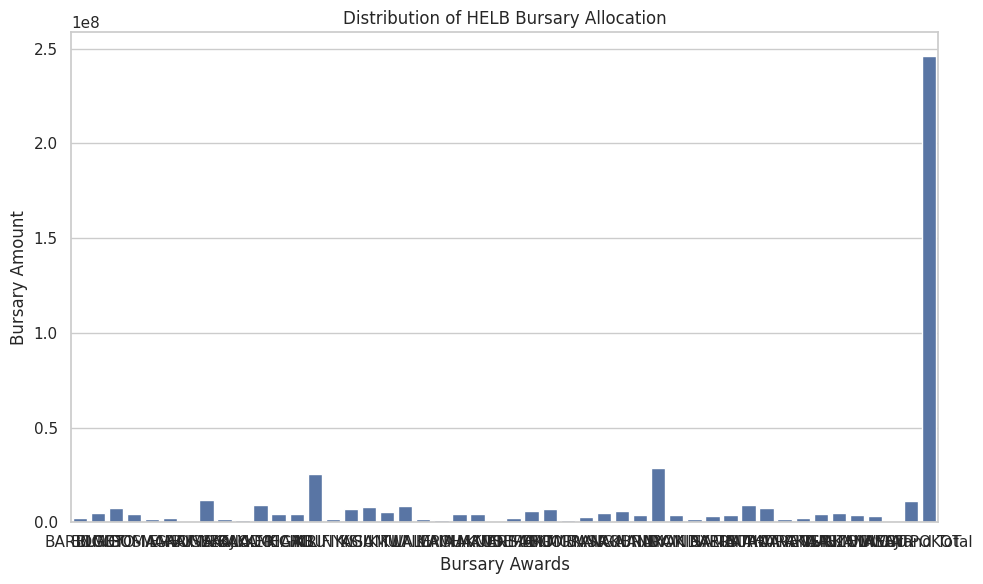

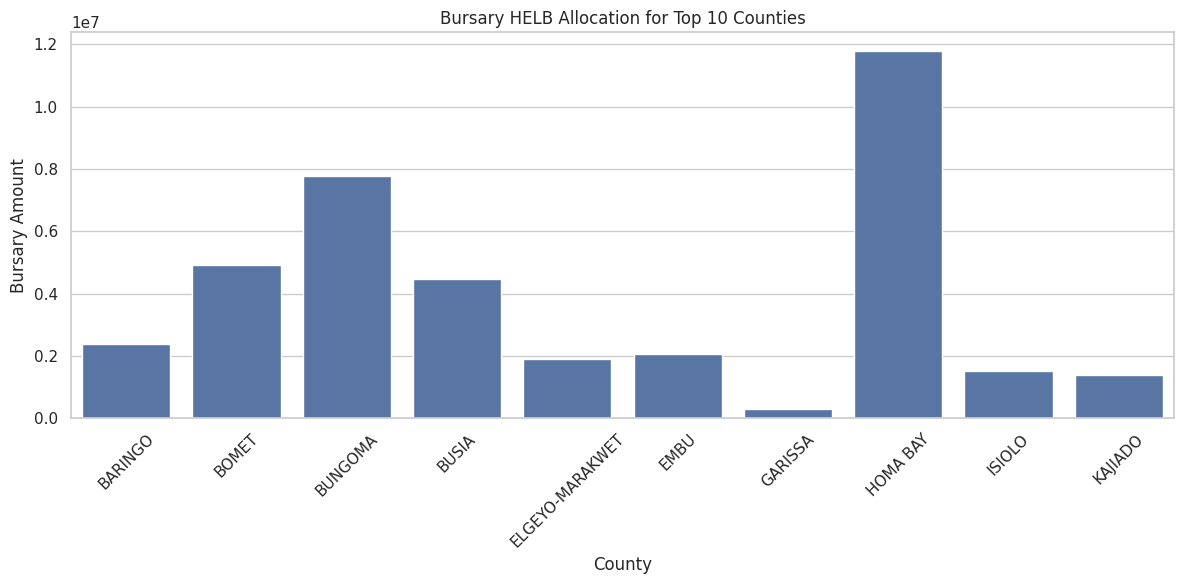

/tmp/ipython-input-53-1605780553.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='County', y='Bursary Awards', data=top_award_counties, palette='crest')


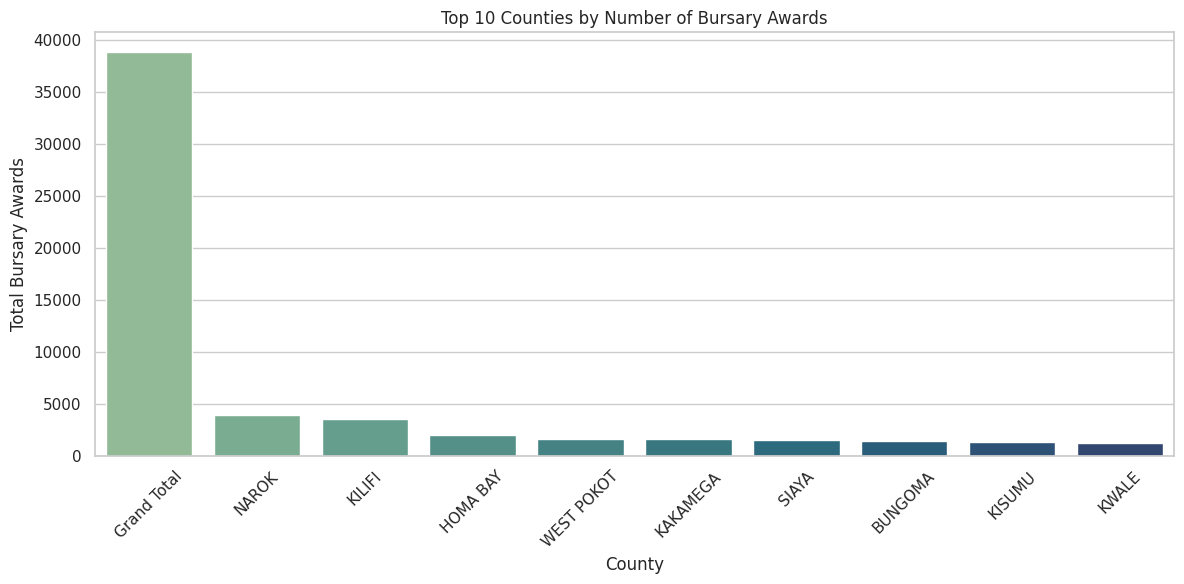

In [53]:
# Load the Excel file (update the file path if necessary)
file_path = "/content/Bursary.xlsx"
df = pd.read_excel(file_path, sheet_name='Bursary Data')
df.dropna(subset=['County'], inplace=True)


# Plot: Distribution of allocations
plt.figure(figsize=(10, 6))
#sns.histplot(df['Bursary Amount'], bins=30, kde=True, color='blue')
#sns.barplot(x='Bursary Awards', y='Bursary Amount', data=df[df['County'].isin(top_counties)], estimator=np.mean)
sns.barplot(x='County', y='Bursary Amount', data=df)
plt.title("Distribution of HELB Bursary Allocation")
plt.xlabel("Bursary Awards")
plt.ylabel("Bursary Amount")
plt.tight_layout()
plt.show()



# Plot: Bursary allocation by county (top 10)
top_counties = df['County'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.barplot(x='County', y='Bursary Amount', data=df[df['County'].isin(top_counties)], estimator=np.mean)
plt.title("Bursary HELB Allocation for Top 10 Counties")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Get top 10 counties by awards
# Group data to get total bursary awards per county
award_totals = df.groupby('County', as_index=False)['Bursary Awards'].sum()
top_award_counties = award_totals.sort_values(by='Bursary Awards', ascending=False).head(10)

# Plot: Top 10 counties by number of bursary awards
plt.figure(figsize=(12, 6))
sns.barplot(x='County', y='Bursary Awards', data=top_award_counties, palette='crest')
plt.title("Top 10 Counties by Number of Bursary Awards")
plt.xlabel("County")
plt.ylabel("Total Bursary Awards")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Load the Excel file (update the file path if necessary)
file_path = "/content/Bursary.xlsx"
df = pd.read_excel(file_path, sheet_name='Bursary Data')
df.dropna(subset=['County'], inplace=True)

##GETTING THE AVERAGE AWARD PER EACH STUDENT PER COUNTY
df['Amount per Award'] = df['Bursary Amount'] / df['Bursary Awards']
df.head()

,County,Bursary Awards,Bursary Amount,Amount per Award
0,BARINGO,411.0,2385000.0,5802.919708
1,BOMET,857.0,4920000.0,5740.956826
2,BUNGOMA,1375.0,7761000.0,5644.363636
3,BUSIA,809.0,4469000.0,5524.103832
4,ELGEYO-MARAKWET,349.0,1914000.0,5484.240688


In [29]:
desc_stats = df[['Bursary Awards', 'Bursary Amount', 'Amount per Award']].describe()
print("Descriptive Statistics:\n", desc_stats)


Descriptive Statistics:
        Bursary Awards  Bursary Amount  Amount per Award
count       48.000000    4.800000e+01         48.000000
mean      1619.020833    1.026179e+07       6238.822393
std       5538.247705    3.519574e+07        570.487360
min         25.000000    1.810000e+05       5484.240688
25%        341.750000    2.028000e+06       5736.465542
50%        688.500000    4.208000e+06       6090.802973
75%       1084.500000    6.836250e+06       6621.523479
max      38835.000000    2.462330e+08       7344.827586


In [30]:
correlation = df[['Bursary Awards', 'Bursary Amount']].corr()
print("Correlation between Bursary Awards and Amount:\n", correlation)

Correlation between Bursary Awards and Amount:
                 Bursary Awards  Bursary Amount
Bursary Awards        1.000000        0.999735
Bursary Amount        0.999735        1.000000


In [32]:
print("Top 5 Efficient Counties (Amount per Award):")
print(df[['County', 'Amount per Award']].sort_values(by='Amount per Award', ascending=False).head())
print("\nBottom 5 Efficient Counties:")
print(df[['County', 'Amount per Award']].sort_values(by='Amount per Award').head())

Top 5 Efficient Counties (Amount per Award):
     County  Amount per Award
36  SAMBURU       7344.827586
20     LAMU       7337.016575
13   KILIFI       7249.076967
45    WAJIR       7240.000000
32    NAROK       7203.900709

Bottom 5 Efficient Counties:
             County  Amount per Award
4   ELGEYO-MARAKWET       5484.240688
31            NANDI       5491.851852
3             BUSIA       5524.103832
25             MERU       5603.082852
11          KERICHO       5637.096774


In [33]:
def find_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

award_outliers = find_outliers('Bursary Awards')
amount_outliers = find_outliers('Bursary Amount')

print("Award Outliers:\n", award_outliers[['County', 'Bursary Awards']])
print("\nAmount Outliers:\n", amount_outliers[['County', 'Bursary Amount']])

Award Outliers:
          County  Bursary Awards
13       KILIFI          3521.0
32        NAROK          3948.0
48  Grand Total         38835.0

Amount Outliers:
          County  Bursary Amount
13       KILIFI      25524000.0
32        NAROK      28441000.0
48  Grand Total     246233000.0


/tmp/ipython-input-34-821494626.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


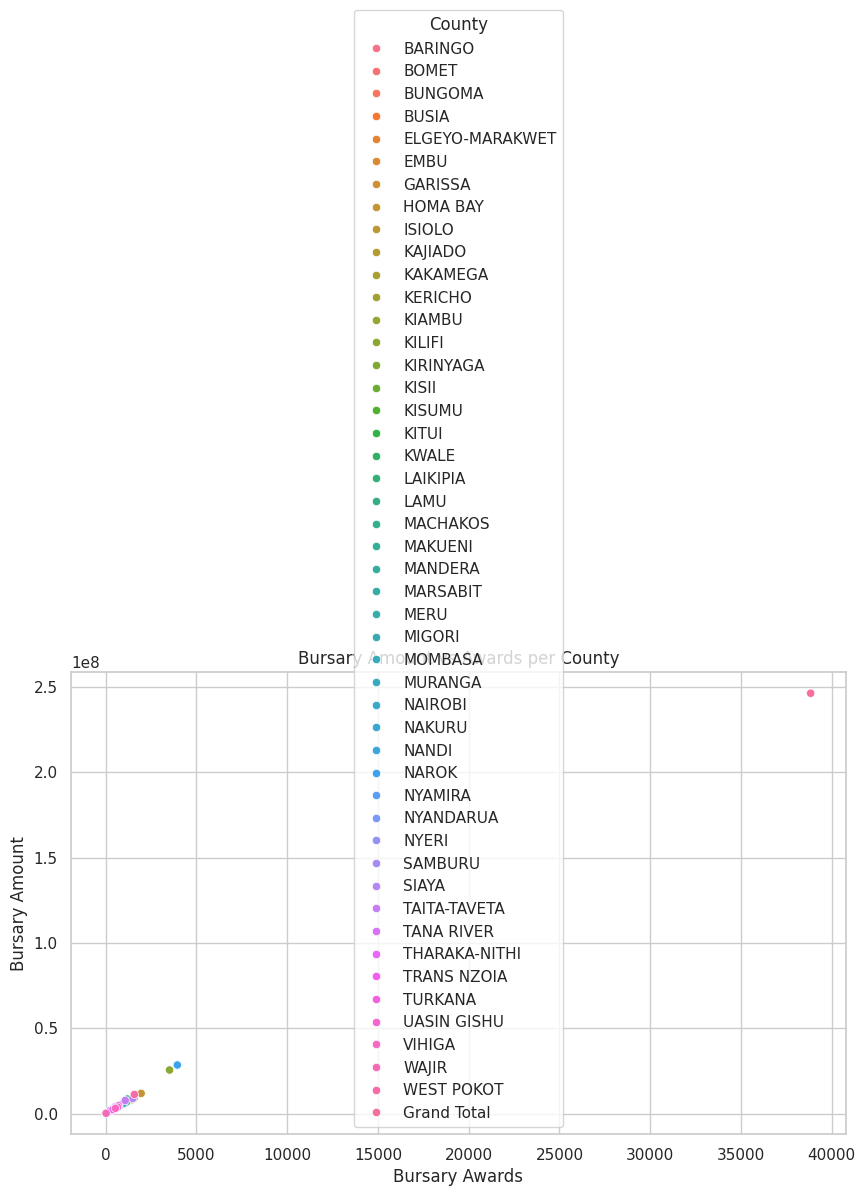

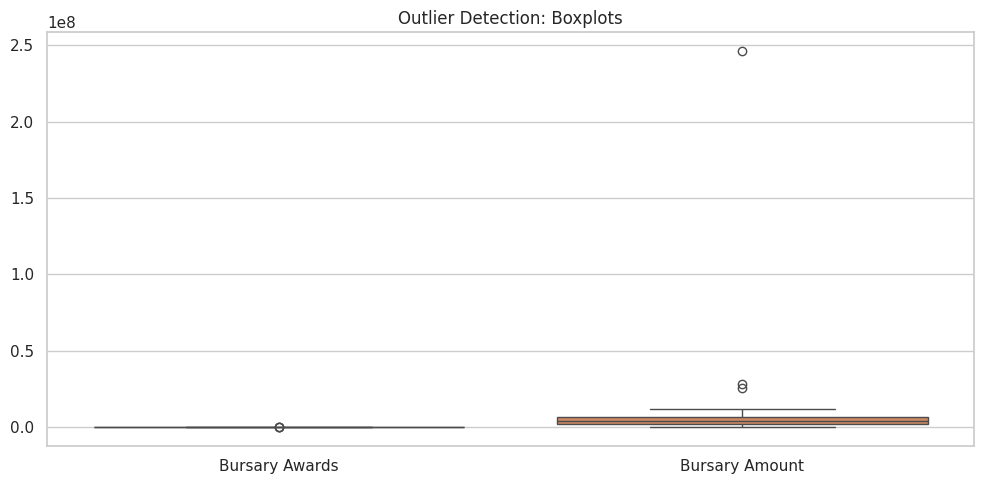

In [34]:
sns.set(style='whitegrid')

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Bursary Awards', y='Bursary Amount', hue='County')
plt.title('Bursary Amount vs Awards per County')
plt.tight_layout()
plt.show()

# Box plots
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Bursary Awards', 'Bursary Amount']])
plt.title('Outlier Detection: Boxplots')
plt.tight_layout()
plt.show()